<a href="https://colab.research.google.com/github/Mithra2022/Gisma_coursework/blob/main/M504D/Mithra_M504D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

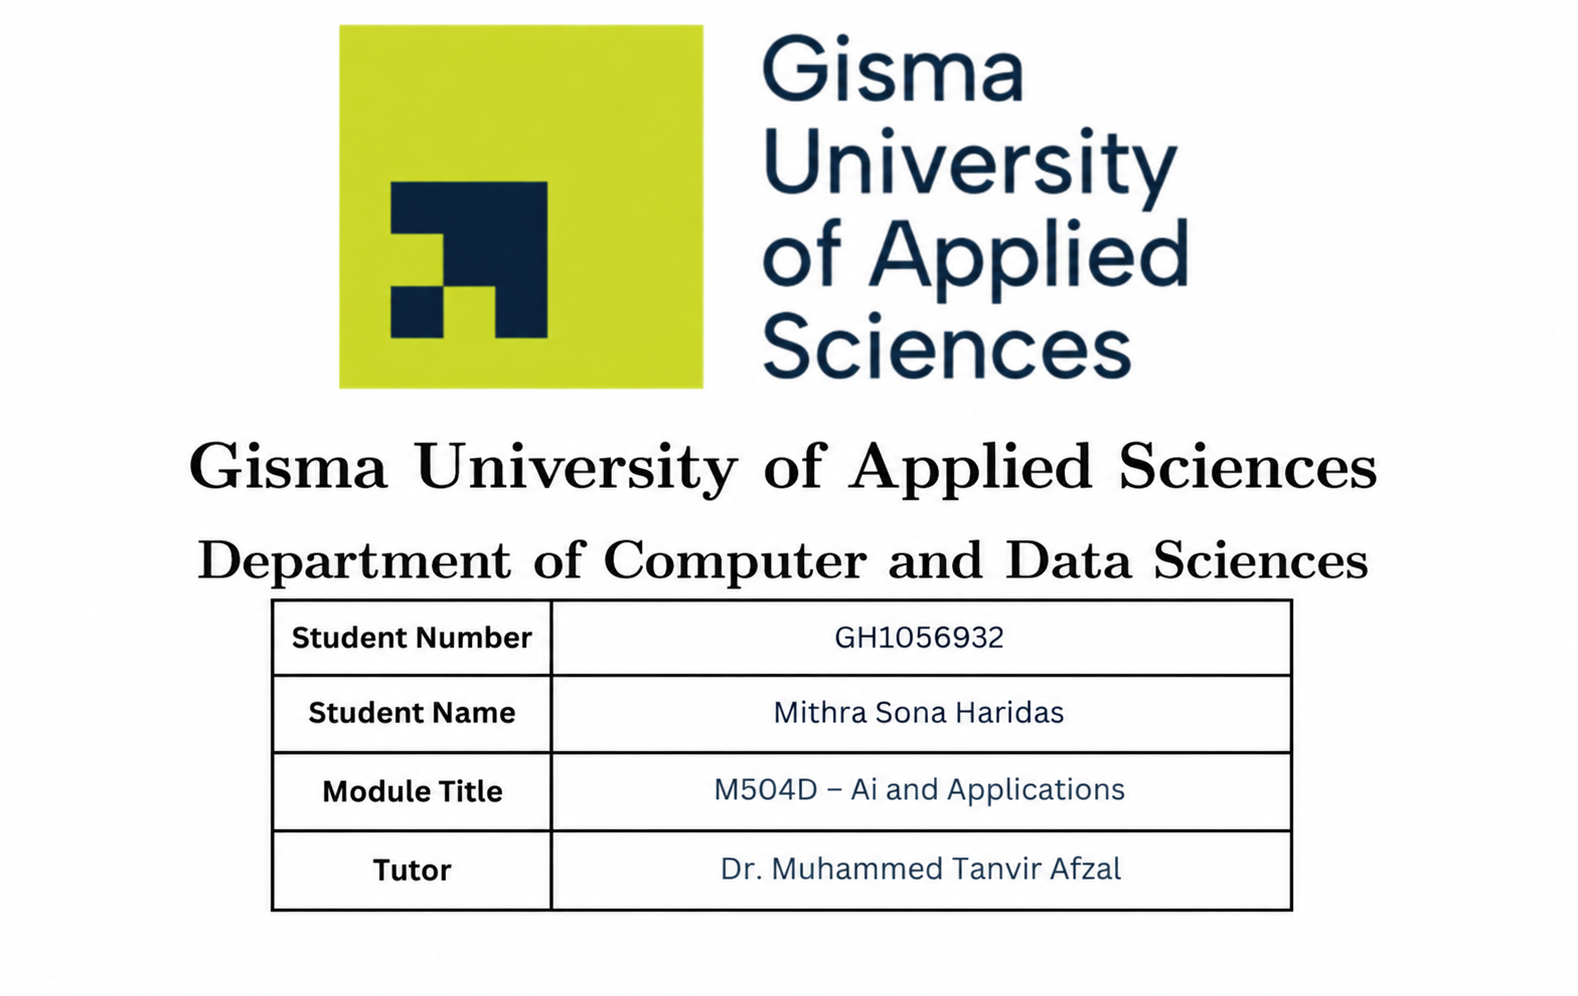

## **Airline Passenger Satisfaction**

### **Introdction**

In this project we examine the passenger reviews from 10 top international airlines to find how it affects their satisfaction and if they would recommend an airline. The notebook includes exploratory data analysis and explanations of how to apply these techniques to clean and explore the data and to answer ten business questions in order to understand the key factors that contribute to positive and negative passenger experiences and areas where airlines can imprve service quality.

Link to the datast : (https://www.kaggle.com/datasets/sujalsuthar/airlines-reviews) by Sujal Suthar, via Kaggle.

### **Business Contxt**

Company: SkyMetrics Consulting

Industry: Travel & Aviation Analytics

Scope: Passenger satisfaction benchmarking across major international airlines

Our client is an group of international airline companies that rely heavily on customer reviews and recommendations for bookings, but lack the in-house expertise and data science skills needed to use their customer feedback to guide their actions. They gave us 8100 reviews from 10 leading airlines in 2023 and they want us to know what makes people happy, who is most affected and the areas of concern. This analysis will inform their service investment decisions, pricing strategies and priorities for customer experience.

In [1]:
#Importing necessary libraries
import pandas as pnd
import matplotlib.pyplot as matplt

matplt.rcParams["figure.dpi"] =70

In [2]:
#Importing the file from kaggle to colab
airline_df = pnd.read_csv("airlines_reviews.csv")

print(airline_df.info())

#Checking rows from the data.
sample_rows =pnd.concat([airline_df.head(2), airline_df.iloc[400:406], airline_df.tail(2)])
sample_rows


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100 entries, 0 to 8099
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Title                   8100 non-null   object
 1   Name                    8100 non-null   object
 2   Review Date             8100 non-null   object
 3   Airline                 8100 non-null   object
 4   Verified                8100 non-null   object
 5   Reviews                 8100 non-null   object
 6   Type of Traveller       8100 non-null   object
 7   Month Flown             8100 non-null   object
 8   Route                   8100 non-null   object
 9   Class                   8100 non-null   object
 10  Seat Comfort            8100 non-null   int64 
 11  Staff Service           8100 non-null   int64 
 12  Food & Beverages        8100 non-null   int64 
 13  Inflight Entertainment  8100 non-null   int64 
 14  Value For Money         8100 non-null   int64 
 15  Over

,Title,Name,Review Date,Airline,Verified,Reviews,Type of Traveller,Month Flown,Route,Class,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money,Overall Rating,Recommended
0,Flight was amazing,Alison Soetantyo,2024-03-01,Singapore Airlines,True,Flight was amazing. The crew onboard this fl...,Solo Leisure,December 2023,Jakarta to Singapore,Business Class,4,4,4,4,4,9,yes
1,seats on this aircraft are dreadful,Robert Watson,2024-02-21,Singapore Airlines,True,Booking an emergency exit seat still meant h...,Solo Leisure,February 2024,Phuket to Singapore,Economy Class,5,3,4,4,1,3,no
400,my worst Economy flight ever,D Keale,2019-10-08,Singapore Airlines,True,Singapore to Adelaide. I dont know what happ...,Business,October 2019,Singapore to Perth,Economy Class,5,5,5,4,1,5,no
401,deterioration in the level of service,C Dalton,2019-10-03,Singapore Airlines,True,Singapore to Perth. Was disappointed with th...,Family Leisure,July 2019,Jakarta to Singapore,Business Class,5,5,1,1,4,8,yes
402,they gave us seafood instead,M Lamis,2019-10-01,Singapore Airlines,True,Jakarta to Singapore. I asked for a Vegetari...,Family Leisure,September 2019,Singapore to Sydney,Economy Class,5,3,5,5,2,3,no
403,Cabin crew were amazing,Angela Reed,2019-10-01,Singapore Airlines,True,Outstanding service from check-in to landing...,Couple Leisure,September 2019,Singapore to Delhi,Economy Class,5,4,2,3,5,10,yes
404,was disappointed again,Guido Bornemann,2019-10-01,Singapore Airlines,True,Singapore to Delhi. After having the experie...,Business,September 2019,Melbourne to Singapore,Economy Class,5,4,5,5,1,1,no
405,found it very unprofessional,D Tan,2019-09-30,Singapore Airlines,True,Melbourne to Singapore. Cabin crew refused t...,Couple Leisure,September 2019,Colombo to Bali via Singapore,Economy Class,4,1,3,4,1,1,no
8098,appreciated the service onboard,E Petan,2016-04-21,Korean Air,False,Seoul to Paris with Korean Air. I am traveli...,Business,April 2016,ICN to CDG,Business Class,5,1,3,4,5,10,yes
8099,genuinely friendly staff,D Lanor,2016-04-12,Korean Air,False,The 13 hour flight in Business class from Se...,Business,April 2016,ICN to YYZ,Business Class,3,5,3,3,5,10,yes


### **Data Preprosessng**

In [3]:
#checking the shape and if there are missing values
print(airline_df.shape)
print(airline_df.isnull().sum())

(8100, 17)
Title                     0
Name                      0
Review Date               0
Airline                   0
Verified                  0
Reviews                   0
Type of Traveller         0
Month Flown               0
Route                     0
Class                     0
Seat Comfort              0
Staff Service             0
Food & Beverages          0
Inflight Entertainment    0
Value For Money           0
Overall Rating            0
Recommended               0
dtype: int64


In [4]:
#checking if there are any duplications in rows
Dupli_count= airline_df.duplicated().sum()
print("DUPLICATE ROWS FOUND:", Dupli_count)

DUPLICATE ROWS FOUND: 0


In [5]:
#Converting Review Date from text to an actual date
airline_df["Review Date"] = pnd.to_datetime(airline_df["Review Date"])
airline_df["Review Date"].head()

,Review Date
0,2024-03-01
1,2024-02-21
2,2024-02-20
3,2024-02-19
4,2024-02-19


In [6]:
#Checking if different values exist in two columns
print(airline_df["Class"].unique())
print(airline_df["Type of Traveller"].unique())

['Business Class' 'Economy Class' 'Premium Economy' 'First Class']
['Solo Leisure' 'Family Leisure' 'Business' 'Couple Leisure']


In [7]:
#Dropping rows with messy data
print(airline_df["Verified"].unique())
before_rows = len(airline_df)
airline_df = airline_df[airline_df["Verified"].isin(["True", "False"])]
after_rows = len(airline_df)
print("rows before:", before_rows, "rows after:", after_rows)

['True' 'False' '*Unverified*' 'NotVerified'
 'we do appreciate you bringing this matter to our attention. Please accept my apologies for not having met your expectations; I do hope that we can leave you and your family with a more positive impression on your future flights with us']
rows before: 8100 rows after: 8097


In [8]:
#Checking column count
Before = len(airline_df.columns)
print("Before:",Before)

Before: 17


In [9]:
#Adding a new column
servce_colmn = ["Seat Comfort", "Staff Service", "Food & Beverages", "Inflight Entertainment", "Value For Money"]
airline_df["Average Service Score"] = airline_df[servce_colmn].mean(axis=1).round(2)
airline_df["Average Service Score"].head()

#Checking column count after adding new column.
After = len(airline_df.columns)
print("After:", After)

After: 18


### **Explnatory Data Analysis**

**B.Q One**: Does verified reviewers have a different rank to unverified review? (trust gap)

We're testing to see if there's any difference in rating between verified reviewers and unverified reviewers. That is important because both are mixed together in public ratings, with unverified ratings potentially over or under representing what the customers are seeing.

In [10]:
#comparing average overall rating
trust_gap = airline_df.groupby("Verified")["Overall Rating"].mean().round(2)
trust_gap

,Overall Rating
Verified,
False,5.83
True,5.57


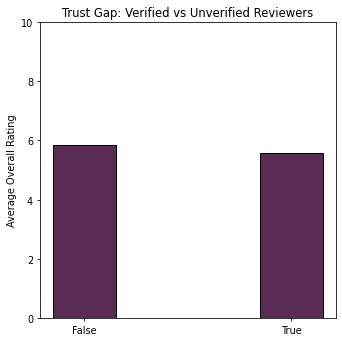

In [11]:
labels = trust_gap.index.astype(str).tolist()
values = trust_gap.values

matplt.figure(figsize=(5,5))
matplt.bar(labels, values, color="#5A2B54", edgecolor='black', width=0.3)
matplt.ylabel('Average Overall Rating')
matplt.title('Trust Gap: Verified vs Unverified Reviewers')
matplt.ylim(0, 10)
matplt.tight_layout()
matplt.show()

Analysing the result

The average score for unverified reviews was 5.83 and the average score for verified reviews was 5.57. The public's rating of the customer may be a bit higher than what the actual passenger experiences, so the company should give more weight to verified ratings

**B.Q Two :** Which service factor has the biggest difference between customers who recommend the airline and those who do not?


By using an average score for each of the 5 service factors, you can determine which service factor most moves customers to recommend an airline, rather than make an educated guess. This will inform airlines of where they should spend their resources.

In [12]:
# comparing average scores for each service factor
service_cols = ["Seat Comfort", "Staff Service", "Food & Beverages", "Inflight Entertainment", "Value For Money"]
airline_df.groupby("Recommended")[service_cols].mean().round(2)

,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money
Recommended,,,,,
no,3.13,3.23,3.16,3.48,1.75
yes,3.67,3.87,3.59,3.78,4.39


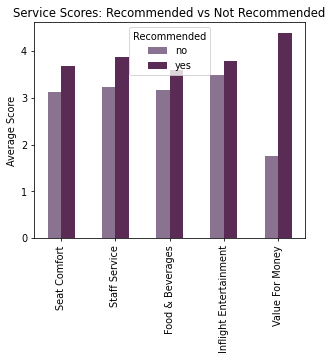

In [13]:
#drafting bar chart
airline_df.groupby("Recommended")[service_cols].mean().round(2).T.plot(kind="bar", color=["#8A7391", "#5A2B54"],figsize=(5,4))
matplt.ylabel("Average Score")
matplt.title("Service Scores: Recommended vs Not Recommended")
matplt.show()

Analysing the result

The gap between the recommenders and non-recommenders was by far the largest for Value For Money. This demonstrates that perceived value and price are a much higher priority to recommendations than comfort or entertainment, a good thing for product and pricing teams to know when deciding where to invest

**B.Q Three :** Does the average satisfaction level increase or decrease with time?

The average rating over the years can determine the trend of customer satisfaction over a period of time. This will tell the business if recent changes are beneficial or detrimental.

In [14]:
#getting the year from Review Date
airline_df["Review Year"] = airline_df["Review Date"].dt.year
airline_df["Review Year"].unique()

#average overall rating per year
yearly_rating = airline_df.groupby("Review Year")["Overall Rating"].mean().round(2)
yearly_rating

,Overall Rating
Review Year,
2016,6.86
2017,6.66
2018,5.77
2019,5.38
2020,5.04
2021,4.67
2022,4.76
2023,5.08
2024,4.93


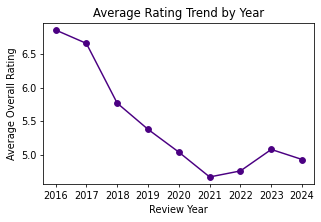

In [15]:
#line chart showing average rating trend over the years
yearly_rating.plot(kind="line", marker="o", color="indigo",figsize=(5,3))
matplt.ylabel("Average Overall Rating")
matplt.title("Average Rating Trend by Year")
matplt.show()

Rating fell sharply from 6.86 in 2016 to 4.67 in 2021, likely tied to pandemic-era disruption, then recovered slightly to 4.93-5.08 by 2022-2024. This indicates that some improvement has been made, but it is not to the 2018 standards of satisfaction.

**B.Q Four:** Are there any differences between the Average Service Score and the Overall Rating ?


Helps in comparing  the avg service score, and in finding out whether something outside the measured in one of the five service areas.


In [16]:
#comparing average service score vs overall rating
service_vs_overall = airline_df[["Average Service Score", "Overall Rating"]].mean().round(2)
service_vs_overall

,0
Average Service Score,3.43
Overall Rating,5.63


In [17]:
#converting Avg Service Score to a 10-point scale so it's comparable to Overall Rating
service_scaled = (airline_df["Average Service Score"] / 5) * 10
overall = airline_df["Overall Rating"]

print("Average Service Score (scaled to 10):", round(service_scaled.mean(), 2))
print("Average Overall Rating:", round(overall.mean(), 2))

Average Service Score (scaled to 10): 6.86
Average Overall Rating: 5.63


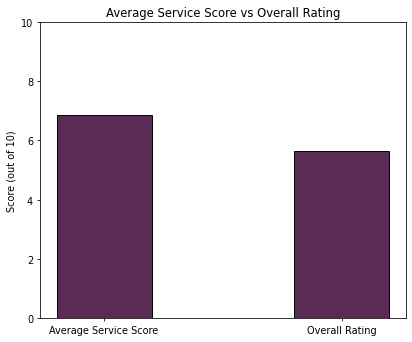

In [18]:
#Bar chart comparing average service score vs overall rating (both scaled to 10)
import matplotlib.pyplot as plt

labels = ['Average Service Score', 'Overall Rating']
values = [service_scaled.mean(), overall.mean()]

plt.figure(figsize=(6,5))
plt.bar(labels, values, color="#5A2B54", edgecolor='black',width=0.4)
plt.ylabel('Score (out of 10)')
plt.title('Average Service Score vs Overall Rating')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

When average service scores were scaled up to a 10-point metric, the score was 6.86 compared with an overall score of just 5.63. This difference indicates that there are other factors affecting overall satisfaction that are not measured, such as delays or pricing.

**B.Q Five:** What is the combination of traveller type + class that is recommended the least?

When looking at traveller type and class together, not just traveller type, or just traveller class, it becomes absolutely clear which segment of customers is least satisfied.

In [19]:
#Percentage recommended, broken down by traveller type and class
recommend_pct = airline_df.groupby(["Type of Traveller", "Class"])["Recommended"].apply(
    lambda x: (x == "yes").mean() * 100
).round(1)
recommend_pct.sort_values()

Type of Traveller  Class          
Couple Leisure     Economy Class      41.2
Family Leisure     Economy Class      43.1
                   First Class        45.5
Business           Economy Class      46.4
                   Premium Economy    48.3
Couple Leisure     Premium Economy    50.4
Solo Leisure       Economy Class      52.6
Business           Business Class     53.8
Family Leisure     Premium Economy    54.9
                   Business Class     66.2
Solo Leisure       Premium Economy    66.4
Couple Leisure     Business Class     68.1
Business           First Class        69.6
Couple Leisure     First Class        75.0
Solo Leisure       Business Class     75.9
                   First Class        84.3
Name: Recommended, dtype: float64

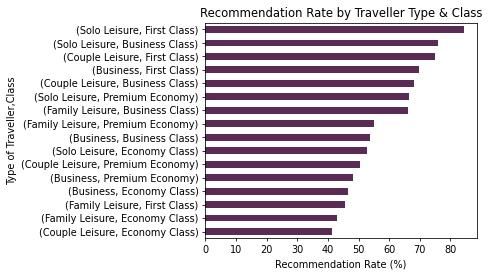

In [20]:
# horizontal bar chart of recommendation rate by traveller type + class
#kind=barh (for horizontal bar)
recommend_pct.sort_values().plot(kind="barh", color="#5A2B54", figsize=(5,4))
matplt.xlabel("Recommendation Rate (%)")
matplt.title("Recommendation Rate by Traveller Type & Class")
matplt.show()

This reveals a clear trend, regardless of traveller type, the likelihood of recommendation increases with the increasing travel class. The percentage of people who recommend a particular class of travel increases gradually as one goes up the classes of travel, from 41.2 per cent for Economy combinations to 84.3 per cent for First Class. The economy market, primarily composed of families and couples, is the highest-risk market for the business.

**B.Q Six :** With the same rating level, are Business travellers more forgiving than Leisure travellers

It allows customer relationship teams to understand who among the travellers they are supporting needs more than "okay" from their experiences to remain satisfied, and who is more okay with an average trip.


In [21]:
#looking only at mid-range ratings (5-6), comparing recommendation rate by traveller type
mid_ratings = airline_df[(airline_df["Overall Rating"] >= 5) & (airline_df["Overall Rating"] <= 6)]

forgiveness = mid_ratings.groupby("Type of Traveller")["Recommended"].apply(
    lambda x: (x == "yes").mean() * 100
).round(1)
forgiveness.sort_values(ascending=False)

,Recommended
Type of Traveller,
Solo Leisure,50.3
Business,47.0
Family Leisure,44.6
Couple Leisure,36.9


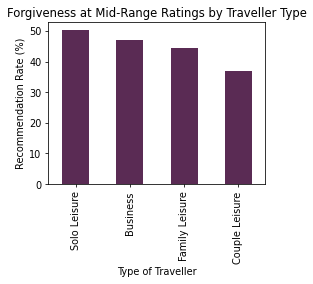

In [22]:
#Bar chart: recommendation rate by traveller type
forgiveness.sort_values(ascending=False).plot(kind="bar", color="#5A2B54", figsize=(4,3))
matplt.ylabel("Recommendation Rate (%)")
matplt.title("Forgiveness at Mid-Range Ratings by Traveller Type")
matplt.show()

The Solo Leisure travellers were most likely to still recommend (50.3%) and the Couple Leisure travellers were least likely to do so (36.9%) at mid-range ratings. The couples must have a steady good experience to get a recommendation

**B.Q Seven :** Is there any existing weak points in airlines of each of the 5 service factors?

The internal improvement plan can be more useful than an industry-wide average by comparing each airline's own 5 service scores to see which one has the weakest point.

In [23]:
# average of each service factor, per airline
service_cols = ["Seat Comfort", "Staff Service", "Food & Beverages", "Inflight Entertainment", "Value For Money"]
airline_service = airline_df.groupby("Airline")[service_cols].mean().round(2)
airline_service

,Seat Comfort,Staff Service,Food & Beverages,Inflight Entertainment,Value For Money
Airline,,,,,
Air France,2.92,3.27,3.10,3.13,2.67
All Nippon Airways,4.14,4.51,4.05,3.93,4.17
Cathay Pacific Airways,3.62,3.62,3.24,3.82,3.33
EVA Air,4.02,4.26,3.88,3.83,4.00
Emirates,3.21,2.97,3.00,3.72,2.75
Japan Airlines,3.90,4.24,3.79,3.56,3.77
Korean Air,3.68,3.85,3.55,3.36,3.56
Qatar Airways,3.97,4.29,3.93,4.12,3.80
Singapore Airlines,3.68,3.94,3.55,3.89,3.45


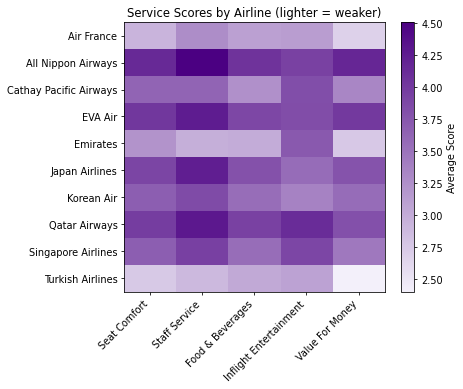

In [24]:
# heatmap showing each airline's score across all 5 service factors, in shades of indigo
from matplotlib.colors import LinearSegmentedColormap
indigo_cmap = LinearSegmentedColormap.from_list("indigo_scale", ["#F3F0FA", "#4B0082"])

matplt.figure(figsize=(6,5))
matplt.imshow(airline_service, cmap=indigo_cmap, aspect="auto")
matplt.colorbar(label="Average Score")
matplt.xticks(range(len(service_cols)), service_cols, rotation=45, ha="right")
matplt.yticks(range(len(airline_service)), airline_service.index)
matplt.title("Service Scores by Airline (lighter = weaker)")
matplt.show()

Value For Money was the most common weak point with 5 of the 10 airlines having poor ratings, while Inflight Entertainment was next in line. This is signifying that pricing/value is not only the largest internal problem for the industry, but it's the largest internal problem for each airline.

**B.Q Eight :** Are there any individual service scores have a "no" recommendation,but still has high individual service score



This supports customer insight teams to gain insight into the dimensions of loyalty to the service, not just those that can be measured.

In [25]:
#reviews where average service score was high (4+) but they still said no
high_service_no_recommend = airline_df[(airline_df["Average Service Score"] >= 4) & (airline_df["Recommended"] == "no")]

print("count of these cases:", len(high_service_no_recommend))
print("out of total 'no' reviews:", (airline_df["Recommended"] == "no").sum())

count of these cases: 420
out of total 'no' reviews: 3811


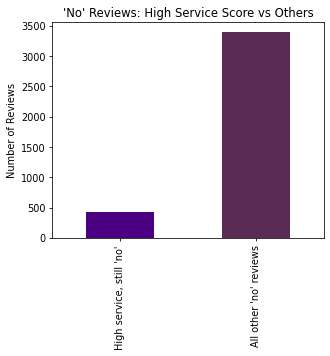

In [26]:
#bar chart of high service scores but still said no, vs the other 'no' reviews
counts = pnd.Series({
    "High service, still 'no'": len(high_service_no_recommend),
    "All other 'no' reviews": (airline_df["Recommended"] == "no").sum() - len(high_service_no_recommend)
})
counts.plot(kind="bar", color=["indigo", "#5A2B54"], figsize=(5,4))
matplt.ylabel("Number of Reviews")
matplt.title("'No' Reviews: High Service Score vs Others")
matplt.show()

420 of 3,811 'no' reviews were from passengers who gave a high rating for the service but were not likely to recommend the airline. This indicates that the 5 measured areas do not fully account for dissatisfaction, so it is worthwhile to explore the written review tex

###**Conclusion**
-Value For Money was the leading factor of dissatisfaction (Q2, Q7)

-Overall satisfaction was lower than in 2016, probably due to the pandemic, and improved only slightly since (Q3).

-Economy Passengers are least likely to recommend their airline (Q5),
particularly couples and families.

-Service scores don't capture the total satisfaction (Q4, Q10) entirely, suggesting that there are other factors that are not measured such as delays or pricing.

### **Limitations**

-Only covers the airlines with the highest ratings in 2023 and does not provide coverage of the entire airline industry especially budget or lower rated airlines.

-Only includes Review date through 2024, so some gaps we saw (Q4, Q10, etc.) may be due to factors we were not able to test directly.

### **Business recommendations**

-Focus on improved perceived value for money over comfort, food and entertainment.

-Target Economy Class, particularly those in couples and families and explore Dubai-London and Christmas/January and July-September.

-The 5 service categories that are not measured and use them to bridge the service score gap and boost overall satisfaction.


### **References**

Suthar, S. (2022) *Airline Reviews Dataset* [Dataset]. Kaggle. Available at: https://www.kaggle.com/datasets/sujalsuthar/airlines-reviews (Accessed: [date you downloaded it]).

The McKinney, W. (2010) 'Data Structures for Statistical Computing in Python', *Proceedings of the 9th Python in Science Conference*, pp. 56–61. Available at: https://pandas.pydata.org/ (Accessed: [date]).

Hunter, J.D. (2007) 'Matplotlib: A 2D Graphics Environment', *Computing in Science & Engineering*, 9(3), pp. 90–95. Available at: https://matplotlib.org/ (Accessed: [date]).